# African Credit Scoring Challenge — Senior ML Pipeline

**Author:** Senior ML Engineer  
**Date:** 2026-04  

## Overview
- **Train:** Kenya loans only  
- **Test:** Kenya + Ghana loans → model must generalise *cross-country*  
- Each row = one lender's share of a loan (same `tbl_loan_id` can have multiple `lender_id` rows)  
- External economic indicators from FRED enriched per country × year  

## Strategy
1. Rigorous EDA & class-imbalance diagnostics  
2. Rich feature engineering — temporal, financial ratios, multi-lender aggregations, macro-economic indicators  
3. No target leakage — all feature engineering on combined (train+test) data before re-splitting  
4. Cross-validated ensemble: **LightGBM + XGBoost + CatBoost**  
5. F1-optimal threshold tuning on out-of-fold (OOF) predictions  


## 0. Setup & Imports

In [1]:
# -- force UTF-8 on Windows consoles
import sys, io
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")
elif hasattr(sys.stdout, "buffer"):
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer,
                                  encoding="utf-8", errors="replace")

# -- auto-install any missing packages
import subprocess, importlib

def _ensure(pip_name, import_name=None):
    mod = import_name or pip_name
    try:
        return importlib.import_module(mod)
    except ImportError:
        print(f"  pip install {pip_name} ...")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", pip_name, "-q"],
            stderr=subprocess.DEVNULL,
        )
        return importlib.import_module(mod)

_ensure("lightgbm")
_ensure("xgboost")
_ensure("scikit-learn", "sklearn")


  pip install lightgbm ...


<module 'sklearn' from 'c:\\Users\\mahab\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\sklearn\\__init__.py'>

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, classification_report,
    precision_recall_curve, ConfusionMatrixDisplay,
)
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb
import xgboost as xgb
CATBOOST_AVAILABLE = False
try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
    print("[OK] CatBoost available")
except ImportError:
    print("  CatBoost not installed -- running LGB + XGB only.")

print(f"Python   : {sys.version.split()[0]}")
print(f"LightGBM : {lgb.__version__}")
print(f"XGBoost  : {xgb.__version__}")
print(f"NumPy    : {np.__version__}")
print(f"Pandas   : {pd.__version__}")

# Reproducibility
RANDOM_STATE = 42
N_FOLDS      = 5

# Paths
DATA_DIR        = Path(".")
TRAIN_PATH      = DATA_DIR / "Train.csv"
TEST_PATH       = DATA_DIR / "Test.csv"
ECON_PATH       = DATA_DIR / "economic_indicators.csv"
SUBMISSION_PATH = DATA_DIR / "SampleSubmission.csv"
OUTPUT_PATH     = DATA_DIR / "submission.csv"


  CatBoost not installed -- running LGB + XGB only.
Python   : 3.12.9
LightGBM : 4.6.0
XGBoost  : 3.0.2
NumPy    : 2.1.3
Pandas   : 2.3.0


## 1. Load Data

In [3]:
train               = pd.read_csv(TRAIN_PATH)
test                = pd.read_csv(TEST_PATH)
econ_raw            = pd.read_csv(ECON_PATH)
submission_template = pd.read_csv(SUBMISSION_PATH)

print(f"Train shape      : {train.shape}")
print(f"Test  shape      : {test.shape}")
print(f"Submission shape : {submission_template.shape}")


Train shape      : (68654, 16)
Test  shape      : (18594, 15)
Submission shape : (18594, 2)


In [4]:
display(train.head())


,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target
0,ID_266671248032267278,266671,Kenya,248032,267278,Type_1,8448.0,8448.0,2022-08-30,2022-09-06,7,Repeat Loan,120.85,0.014305,121.0,0
1,ID_248919228515267278,248919,Kenya,228515,267278,Type_1,25895.0,25979.0,2022-07-30,2022-08-06,7,Repeat Loan,7768.50,0.300000,7794.0,0
2,ID_308486370501251804,308486,Kenya,370501,251804,Type_7,6900.0,7142.0,2024-09-06,2024-09-13,7,Repeat Loan,1380.00,0.200000,1428.0,0
3,ID_266004285009267278,266004,Kenya,285009,267278,Type_1,8958.0,9233.0,2022-10-20,2022-10-27,7,Repeat Loan,2687.40,0.300000,2770.0,0
4,ID_253803305312267278,253803,Kenya,305312,267278,Type_1,4564.0,4728.0,2022-11-28,2022-12-05,7,Repeat Loan,1369.20,0.300000,1418.0,0


In [5]:
print("Data types:")
print(train.dtypes)
print(f"\nMissing (train) : {train.isna().sum().sum()}")
print(f"Missing (test)  : {test.isna().sum().sum()}")


Data types:
ID                              object
customer_id                      int64
country_id                      object
tbl_loan_id                      int64
lender_id                        int64
loan_type                       object
Total_Amount                   float64
Total_Amount_to_Repay          float64
disbursement_date               object
due_date                        object
duration                         int64
New_versus_Repeat               object
Amount_Funded_By_Lender        float64
Lender_portion_Funded          float64
Lender_portion_to_be_repaid    float64
target                           int64
dtype: object

Missing (train) : 0
Missing (test)  : 0


## 2. Exploratory Data Analysis

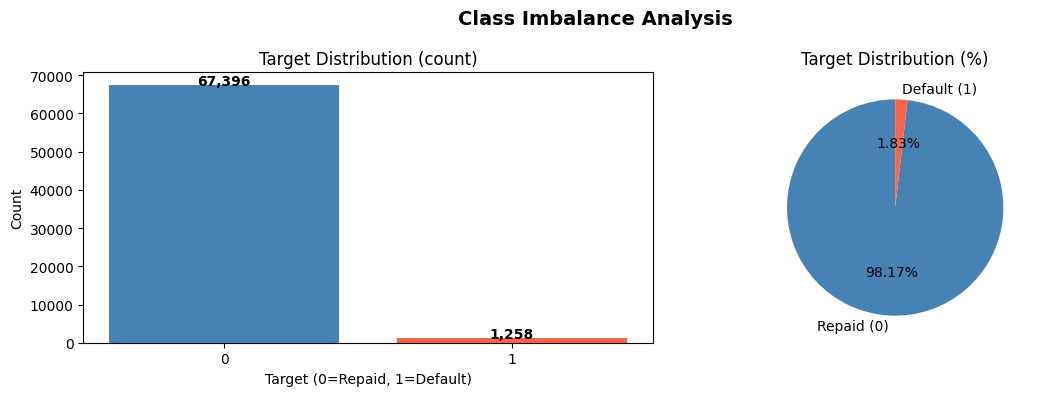


Imbalance ratio (0:1) = 53.6x -- severe imbalance, need class weighting or resampling


In [6]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = train["target"].value_counts()
axes[0].bar(counts.index.astype(str), counts.values, color=["steelblue", "tomato"])
axes[0].set_title("Target Distribution (count)")
axes[0].set_xlabel("Target (0=Repaid, 1=Default)")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontweight="bold")

axes[1].pie(counts.values, labels=["Repaid (0)", "Default (1)"],
            autopct="%1.2f%%", colors=["steelblue", "tomato"], startangle=90)
axes[1].set_title("Target Distribution (%)")

plt.suptitle("Class Imbalance Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

imb = counts[0] / counts[1]
print(f"\nImbalance ratio (0:1) = {imb:.1f}x -- severe imbalance, need class weighting or resampling")


In [7]:
# Country breakdown
print("=== Countries ===")
print("Train:", sorted(train["country_id"].unique()))
print("Test :", sorted(test["country_id"].unique()))
print()
print("=== Loan type cardinality ===")
print("Train loan types:", train["loan_type"].nunique())
print(train["loan_type"].value_counts().head(10))


=== Countries ===
Train: ['Kenya']
Test : ['Ghana', 'Kenya']

=== Loan type cardinality ===
Train loan types: 22
loan_type
Type_1     61723
Type_7      2790
Type_5      1521
Type_4      1235
Type_10      466
Type_6       357
Type_9       205
Type_14       99
Type_2        74
Type_11       42
Name: count, dtype: int64


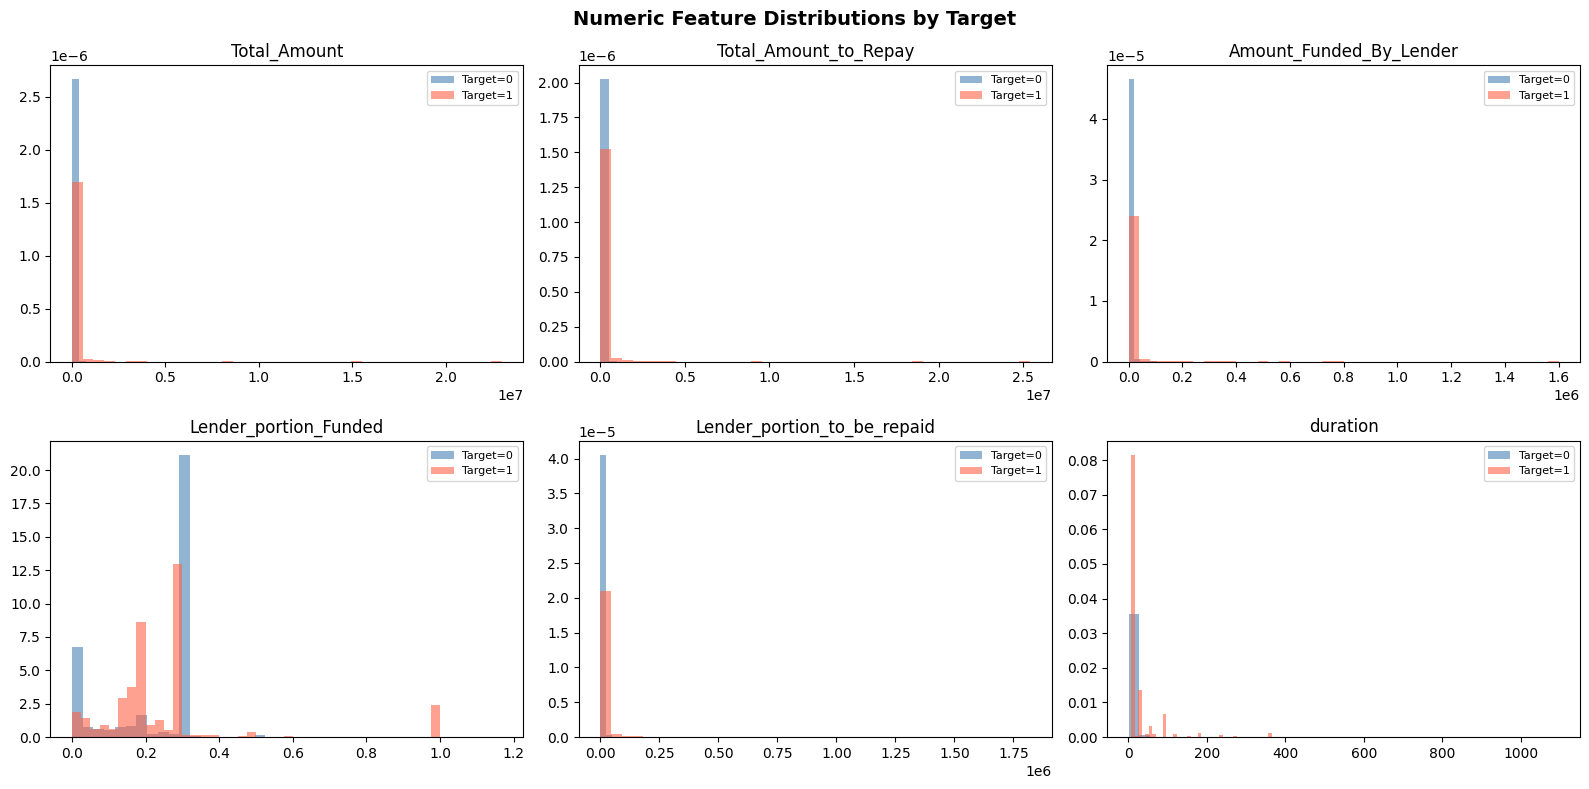

In [8]:
# Numeric feature distributions
num_cols = ["Total_Amount", "Total_Amount_to_Repay",
            "Amount_Funded_By_Lender", "Lender_portion_Funded",
            "Lender_portion_to_be_repaid", "duration"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols):
    for cls, color in [(0, "steelblue"), (1, "tomato")]:
        data = train.loc[train["target"] == cls, col]
        ax.hist(data, bins=40, alpha=0.6, color=color,
                label=f"Target={cls}", density=True)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.legend(fontsize=8)
plt.suptitle("Numeric Feature Distributions by Target", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [9]:
# New vs Repeat loan default rate
nvr = train.groupby("New_versus_Repeat")["target"].agg(["mean", "count"])
nvr.columns = ["Default Rate", "Count"]
print("New vs Repeat Loan Default Rates:")
display(nvr)

# Loan type default rates (top 10)
lt_dr = (train.groupby("loan_type")["target"]
         .agg(default_rate="mean", count="count")
         .sort_values("default_rate", ascending=False)
         .head(10))
print("\nTop 10 Loan Types by Default Rate:")
display(lt_dr)


New vs Repeat Loan Default Rates:


,Default Rate,Count
New_versus_Repeat,,
New Loan,0.209877,567
Repeat Loan,0.016729,68087



Top 10 Loan Types by Default Rate:


,default_rate,count
loan_type,,
Type_15,0.750000,4
Type_23,0.722222,18
Type_14,0.717172,99
Type_2,0.608108,74
Type_20,0.538462,13
Type_9,0.175610,205
Type_4,0.123077,1235
Type_6,0.106443,357
Type_7,0.084229,2790


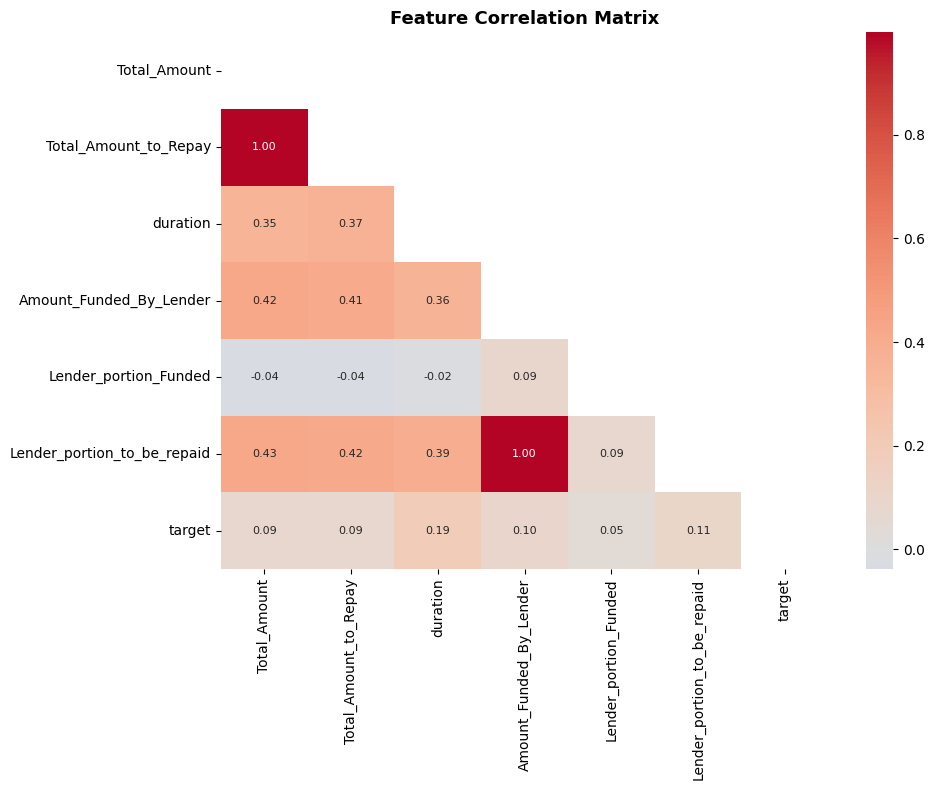

In [10]:
# Correlation heatmap
num_train = train.select_dtypes(include=np.number).drop(
    columns=["customer_id", "tbl_loan_id", "lender_id"], errors="ignore"
)
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(num_train.corr(), dtype=bool))
sns.heatmap(num_train.corr(), mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax,
            annot_kws={"size": 8})
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 3. Economic Indicators (FRED Data)

In [11]:
# Reshape from wide to long, then pivot to (country, year) x indicator
econ_melted = econ_raw.melt(
    id_vars=["Country", "Indicator"],
    var_name="Year", value_name="Value",
)
econ_melted["Year"] = (
    econ_melted["Year"].str.replace("YR", "", regex=False).astype(int)
)

econ_pivot = (
    econ_melted
    .pivot_table(index=["Country", "Year"],
                 columns="Indicator", values="Value",
                 aggfunc="first")
    .reset_index()
)
econ_pivot.columns.name = None

RENAME_ECON = {
    "Inflation, consumer prices (annual %)":               "econ_inflation",
    "Official exchange rate (LCU per US$, period average)":"econ_exchange_rate",
    "Real interest rate (%)":                              "econ_real_interest",
    "Average precipitation in depth (mm per year)":        "econ_precipitation",
    "Deposit interest rate (%)":                           "econ_deposit_rate",
    "Lending interest rate (%)":                           "econ_lending_rate",
    "Interest rate spread (lending rate minus deposit rate, %)": "econ_rate_spread",
    "Fossil fuel energy consumption (% of total)":         "econ_fossil_fuel",
    "Unemployment rate":                                   "econ_unemployment",
}
econ_pivot.rename(columns=RENAME_ECON, inplace=True)
econ_pivot.rename(columns={"Country": "country_econ", "Year": "year_econ"},
                  inplace=True)

ECON_COLS = list(RENAME_ECON.values())
print(f"Economic indicator columns ({len(ECON_COLS)}):")
for c in ECON_COLS:
    print(f"  {c}")
display(econ_pivot.head())


Economic indicator columns (9):
  econ_inflation
  econ_exchange_rate
  econ_real_interest
  econ_precipitation
  econ_deposit_rate
  econ_lending_rate
  econ_rate_spread
  econ_fossil_fuel
  econ_unemployment


,country_econ,year_econ,econ_precipitation,econ_deposit_rate,econ_fossil_fuel,econ_inflation,econ_rate_spread,econ_lending_rate,econ_exchange_rate,econ_real_interest,econ_unemployment
0,Cote d'Ivoire,2001,1348.0,NaN,34.298397,4.361529,NaN,NaN,732.397693,NaN,5.199
1,Cote d'Ivoire,2002,1348.0,NaN,37.848716,3.077265,NaN,NaN,693.713226,NaN,5.516
2,Cote d'Ivoire,2003,1348.0,NaN,32.501441,3.296807,NaN,NaN,579.897426,NaN,5.858
3,Cote d'Ivoire,2004,1348.0,NaN,24.930573,1.457988,NaN,NaN,527.338032,NaN,5.930
4,Cote d'Ivoire,2005,1348.0,7.6075,25.391257,3.885830,-0.558333,7.049167,527.258363,5.763991,6.041


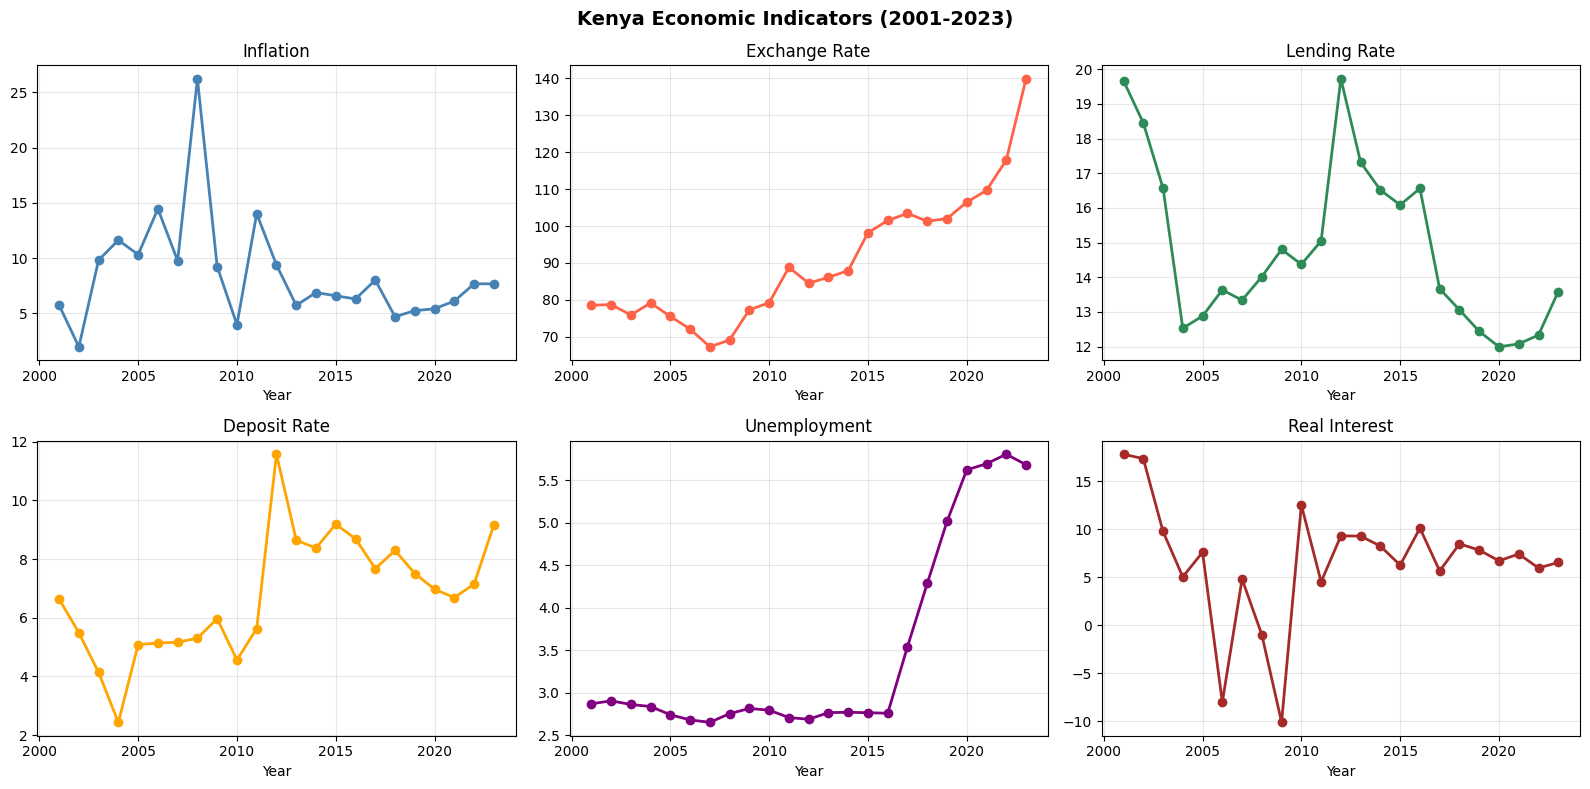

In [12]:
# Visualise key economic indicators for Kenya
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
kenya = econ_pivot[econ_pivot["country_econ"] == "Kenya"]
indicators = ["econ_inflation", "econ_exchange_rate", "econ_lending_rate",
              "econ_deposit_rate", "econ_unemployment", "econ_real_interest"]
colors = ["steelblue", "tomato", "seagreen", "orange", "purple", "brown"]

for ax, col, color in zip(axes.flatten(), indicators, colors):
    data = kenya.dropna(subset=[col])
    ax.plot(data["year_econ"], data[col], marker="o", color=color, lw=2)
    ax.set_title(col.replace("econ_", "").replace("_", " ").title())
    ax.set_xlabel("Year")
    ax.grid(alpha=0.3)

plt.suptitle("Kenya Economic Indicators (2001-2023)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [13]:
def merge_econ(df: pd.DataFrame) -> pd.DataFrame:
    """Merge macro indicators by (country_id, disbursement year)."""
    tmp = df.copy()
    tmp["_year"] = pd.to_datetime(tmp["disbursement_date"]).dt.year
    out = tmp.merge(
        econ_pivot[["country_econ", "year_econ"] + ECON_COLS],
        left_on=["country_id", "_year"],
        right_on=["country_econ", "year_econ"],
        how="left",
    )
    out.drop(columns=["_year", "country_econ", "year_econ"],
             errors="ignore", inplace=True)
    return out

print("merge_econ() function defined.")


merge_econ() function defined.


## 4. Feature Engineering

In [14]:
# ---- Multi-lender loan aggregations (computed on ALL data - no leakage) ----
all_raw = pd.concat([train, test], axis=0, ignore_index=True)

loan_agg = (
    all_raw.groupby("tbl_loan_id", sort=False)
    .agg(
        loan_n_lenders    =("lender_id",              "nunique"),
        loan_total_funded =("Amount_Funded_By_Lender", "sum"),
        loan_max_share    =("Lender_portion_Funded",   "max"),
        loan_min_share    =("Lender_portion_Funded",   "min"),
        loan_std_share    =("Lender_portion_Funded",   "std"),
    )
    .reset_index()
)
loan_agg["loan_std_share"].fillna(0.0, inplace=True)

print(f"Unique loans: {loan_agg['tbl_loan_id'].nunique()}")
print(f"Max lenders on a single loan: {loan_agg['loan_n_lenders'].max()}")
display(loan_agg.describe())


Unique loans: 82667
Max lenders on a single loan: 3


,tbl_loan_id,loan_n_lenders,loan_total_funded,loan_max_share,loan_min_share,loan_std_share
count,82667.000000,82667.000000,8.266700e+04,82667.000000,82667.000000,82667.000000
mean,262872.875658,1.055415,2.626624e+03,0.219062,0.218562,0.000353
std,39135.932126,0.230686,1.320235e+04,0.130511,0.130768,0.006635
min,101323.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,233945.500000,1.000000,2.277000e+02,0.118144,0.111277,0.000000
50%,260068.000000,1.000000,8.742000e+02,0.300000,0.300000,0.000000
75%,286567.500000,1.000000,2.294700e+03,0.300000,0.300000,0.000000
max,375320.000000,3.000000,1.700000e+06,1.168119,1.168119,0.445942


In [16]:
# ---- Customer history from TRAIN only  ----
cust_agg = (
    train.groupby("customer_id", sort=False)
    .agg(
        cust_n_loans      =("tbl_loan_id",  "nunique"),
        cust_avg_amount   =("Total_Amount", "mean"),
        cust_max_amount   =("Total_Amount", "max"),
        cust_default_rate =("target",       "mean"),   # train labels only
    )
    .reset_index()
)

# ---- Lender reliability from TRAIN ----
lender_agg = (
    train.groupby("lender_id", sort=False)
    .agg(
        lender_n_loans      =("tbl_loan_id", "nunique"),
        lender_default_rate =("target",      "mean"),
    )
    .reset_index()
)

print("Customer aggregation shape:", cust_agg.shape)
print("Lender  aggregation shape :", lender_agg.shape)
print()
print("Customer default rate distribution:")
display(cust_agg["cust_default_rate"].describe())


Customer aggregation shape: (6540, 5)
Lender  aggregation shape : (4, 3)

Customer default rate distribution:


count    6540.000000
mean        0.085570
std         0.248099
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: cust_default_rate, dtype: float64

In [17]:
def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    """Build all engineered features from a raw (or semi-processed) dataframe."""
    df = df.copy()

    disb = pd.to_datetime(df["disbursement_date"])
    due  = pd.to_datetime(df["due_date"])

    # -- Temporal features --
    df["disb_year"]          = disb.dt.year          # used as econ merge key
    df["disb_month"]         = disb.dt.month
    df["disb_day"]           = disb.dt.day
    df["disb_weekday"]       = disb.dt.weekday        # 0=Mon
    df["disb_quarter"]       = disb.dt.quarter
    df["disb_week"]          = disb.dt.isocalendar().week.astype(int)
    df["disb_dayofyear"]     = disb.dt.dayofyear
    df["disb_is_weekend"]    = (df["disb_weekday"] >= 5).astype("int8")
    df["disb_is_monthstart"] = disb.dt.is_month_start.astype("int8")
    df["disb_is_monthend"]   = disb.dt.is_month_end.astype("int8")

    df["due_month"]          = due.dt.month
    df["due_weekday"]        = due.dt.weekday
    df["due_quarter"]        = due.dt.quarter
    df["due_is_weekend"]     = (df["due_weekday"] >= 5).astype("int8")

    df["loan_term_days"]     = (due - disb).dt.days
    df["term_vs_duration"]   = df["loan_term_days"] / df["duration"].clip(lower=1)

    df["duration_bucket"] = pd.cut(
        df["duration"],
        bins=[0, 7, 14, 30, 60, 90, 180, 365, np.inf],
        labels=[0, 1, 2, 3, 4, 5, 6, 7],
    ).astype(int)

    # -- Financial ratio features --
    eps = 1e-6
    A   = df["Total_Amount"].clip(lower=eps)
    R   = df["Total_Amount_to_Repay"]
    LF  = df["Amount_Funded_By_Lender"]
    LP  = df["Lender_portion_Funded"]
    LR  = df["Lender_portion_to_be_repaid"]
    DUR = df["duration"].clip(lower=1)

    df["repayment_ratio"]    = R / A
    df["interest_amount"]    = (R - df["Total_Amount"]).clip(lower=0)
    df["interest_pct"]       = df["interest_amount"] / A
    df["lender_share"]       = LF / A
    df["lender_repay_ratio"] = LR / LF.clip(lower=eps)
    df["borrower_portion"]   = (1.0 - LP).clip(0.0, 1.0)
    df["borrower_amount"]    = df["Total_Amount"] * df["borrower_portion"]
    df["borrower_repay"]     = (R - LR).clip(lower=0)
    df["daily_repayment"]    = R / DUR
    df["daily_lender_repay"] = LR / DUR
    df["log_loan"]           = np.log1p(df["Total_Amount"])
    df["log_repay"]          = np.log1p(R)
    df["log_lender_funded"]  = np.log1p(LF)

    df["loan_size_bucket"] = pd.cut(
        df["Total_Amount"],
        bins=[0, 1000, 5000, 20000, 50000, np.inf],
        labels=[0, 1, 2, 3, 4],
    ).astype(int)

    # -- Categorical encoding --
    df["is_repeat_loan"] = (
        df["New_versus_Repeat"].str.strip() == "Repeat Loan"
    ).astype("int8")
    df["loan_type_code"] = LabelEncoder().fit_transform(
        df["loan_type"].astype(str)
    )

    # -- Interaction features --
    df["amount_x_duration"]   = df["Total_Amount"] * df["duration"]
    df["interest_x_duration"] = df["interest_amount"] * df["duration"]
    df["lender_share_x_loan"] = df["lender_share"] * df["log_loan"]
    df["repay_ratio_x_term"]  = df["repayment_ratio"] * df["loan_term_days"]

    return df

print("feature_engineering() function defined.")


feature_engineering() function defined.


## 5. Build Feature Matrix (No Target Leakage)

In [18]:
# Apply to COMBINED data so encodings are consistent across train/test
combined = pd.concat([train, test], axis=0, ignore_index=True)
combined = merge_econ(combined)
combined = feature_engineering(combined)

# Merge aggregation tables
combined = combined.merge(loan_agg,   on="tbl_loan_id",  how="left")
combined = combined.merge(cust_agg,   on="customer_id",  how="left")
combined = combined.merge(lender_agg, on="lender_id",    how="left")

# Fill customer/lender stats for test rows not seen in train
train_mask = combined["ID"].isin(train["ID"])
FILL_COLS  = ["cust_n_loans", "cust_avg_amount", "cust_max_amount",
              "cust_default_rate", "lender_n_loans", "lender_default_rate"]
for col in FILL_COLS:
    med = combined.loc[train_mask, col].median()
    combined[col] = combined[col].fillna(med)

# Drop raw text & date columns
combined.drop(
    columns=["disbursement_date", "due_date",
             "New_versus_Repeat", "loan_type"],
    inplace=True,
)

# One-hot encode country (low cardinality, generalises cross-country)
combined = pd.get_dummies(combined, columns=["country_id"],
                          drop_first=False, dtype=np.int8)

# Re-split
train_fe = combined[combined["ID"].isin(train["ID"])].copy()
test_fe  = combined[~combined["ID"].isin(train["ID"])].copy()

print(f"train_fe shape : {train_fe.shape}")
print(f"test_fe  shape : {test_fe.shape}")


train_fe shape : (68654, 70)
test_fe  shape : (18594, 70)


In [19]:
# Define feature list (exclude identifiers and target)
EXCLUDE = {
    "ID", "target",
    "customer_id", "tbl_loan_id", "lender_id",
    "disb_year",          # used only as merge key
}
FEATURES = [c for c in train_fe.columns if c not in EXCLUDE]

# Label-encode any residual object columns
for col in train_fe[FEATURES].select_dtypes(include="object").columns:
    le = LabelEncoder()
    le.fit(pd.concat([train_fe[col], test_fe[col]]).astype(str))
    train_fe[col] = le.transform(train_fe[col].astype(str))
    test_fe[col]  = le.transform(test_fe[col].astype(str))

# Fill residual NaN with train-median
for col in FEATURES:
    if train_fe[col].isna().any() or test_fe[col].isna().any():
        med = float(train_fe[col].median())
        train_fe[col] = train_fe[col].fillna(med)
        test_fe[col]  = test_fe[col].fillna(med)

# Cast to float32 (required by XGBoost >= 2.0 + faster for LGB/CAT)
X      = train_fe[FEATURES].astype(np.float32).values
y      = train_fe["target"].astype(np.int32).values
X_test = test_fe[FEATURES].astype(np.float32).values

print(f"Feature count   : {len(FEATURES)}")
print(f"Train matrix    : {X.shape}")
print(f"Test  matrix    : {X_test.shape}")
print(f"Positive rate   : {y.mean():.4f}  ({y.sum():,} defaults out of {len(y):,})")


Feature count   : 64
Train matrix    : (68654, 64)
Test  matrix    : (18594, 64)
Positive rate   : 0.0183  (1,258 defaults out of 68,654)


## 6. Model Parameters

In [20]:
scale_pos_weight = float((y == 0).sum()) / float(max((y == 1).sum(), 1))
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

lgb_params = dict(
    objective         = "binary",
    metric            = "auc",
    learning_rate     = 0.05,
    num_leaves        = 127,
    max_depth         = -1,
    min_child_samples = 50,
    feature_fraction  = 0.8,
    bagging_fraction  = 0.8,
    bagging_freq      = 5,
    reg_alpha         = 0.1,
    reg_lambda        = 0.5,
    is_unbalance      = True,   # handles 54:1 imbalance internally
    random_state      = RANDOM_STATE,
    n_estimators      = 3000,
    verbosity         = -1,
    n_jobs            = -1,
)

# XGBoost 3.x: early_stopping_rounds goes in the constructor
xgb_params = dict(
    objective             = "binary:logistic",
    eval_metric           = "auc",
    learning_rate         = 0.05,
    max_depth             = 6,
    n_estimators          = 3000,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    scale_pos_weight      = scale_pos_weight,
    seed                  = RANDOM_STATE,
    verbosity             = 0,
    n_jobs                = -1,
    tree_method           = "hist",
    device                = "cpu",
    early_stopping_rounds = 150,
)

if CATBOOST_AVAILABLE:
    cat_params = dict(
        iterations            = 3000,
        learning_rate         = 0.05,
        depth                 = 6,
        l2_leaf_reg           = 3,
        auto_class_weights    = "Balanced",
        random_seed           = RANDOM_STATE,
        early_stopping_rounds = 150,
        verbose               = 0,
    )
    print("CatBoost params set.")

print("Model parameters configured.")


scale_pos_weight = 53.57
Model parameters configured.


## 7. Cross-Validated Training

Used **5-fold stratified cross-validation** to:
- Get honest **out-of-fold (OOF) predictions** for threshold tuning
- Average test-set predictions across folds (reduces variance)
- Report per-fold AUC to detect instability


In [21]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

oof_lgb  = np.zeros(len(X), dtype=np.float64)
oof_xgb  = np.zeros(len(X), dtype=np.float64)
oof_cat  = np.zeros(len(X), dtype=np.float64)
test_lgb = np.zeros(len(X_test), dtype=np.float64)
test_xgb = np.zeros(len(X_test), dtype=np.float64)
test_cat = np.zeros(len(X_test), dtype=np.float64)

lgb_models, xgb_models, cat_models = [], [], []

for fold_i, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n--- Fold {fold_i}/{N_FOLDS} ---")
    X_tr, X_va = X[tr_idx], X[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    # LightGBM
    lgb_model = lgb.LGBMClassifier(**lgb_params)
    lgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=150, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )
    oof_lgb[va_idx]  = lgb_model.predict_proba(X_va)[:, 1]
    test_lgb        += lgb_model.predict_proba(X_test)[:, 1] / N_FOLDS
    lgb_models.append(lgb_model)
    print(f"  LGB  AUC={roc_auc_score(y_va, oof_lgb[va_idx]):.4f}"
          f"  best_iter={lgb_model.best_iteration_}")

    # XGBoost
    xgb_model = xgb.XGBClassifier(**xgb_params)
    xgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        verbose=False,
    )
    oof_xgb[va_idx]  = xgb_model.predict_proba(X_va)[:, 1]
    test_xgb        += xgb_model.predict_proba(X_test)[:, 1] / N_FOLDS
    xgb_models.append(xgb_model)
    print(f"  XGB  AUC={roc_auc_score(y_va, oof_xgb[va_idx]):.4f}"
          f"  best_iter={xgb_model.best_iteration}")

    # CatBoost
    if CATBOOST_AVAILABLE:
        cat_model = CatBoostClassifier(**cat_params)
        cat_model.fit(X_tr, y_tr,
                      eval_set=(X_va, y_va), use_best_model=True)
        oof_cat[va_idx]  = cat_model.predict_proba(X_va)[:, 1]
        test_cat        += cat_model.predict_proba(X_test)[:, 1] / N_FOLDS
        cat_models.append(cat_model)
        print(f"  CAT  AUC={roc_auc_score(y_va, oof_cat[va_idx]):.4f}")



--- Fold 1/5 ---
  LGB  AUC=0.9998  best_iter=124
  XGB  AUC=0.9998  best_iter=171

--- Fold 2/5 ---
  LGB  AUC=0.9999  best_iter=215
  XGB  AUC=0.9998  best_iter=298

--- Fold 3/5 ---
  LGB  AUC=0.9996  best_iter=240
  XGB  AUC=0.9997  best_iter=216

--- Fold 4/5 ---
  LGB  AUC=0.9999  best_iter=606
  XGB  AUC=0.9999  best_iter=75

--- Fold 5/5 ---
  LGB  AUC=0.9997  best_iter=141
  XGB  AUC=0.9998  best_iter=210


## 8. Ensemble (AUC-Weighted Average)

In [23]:
auc_lgb = roc_auc_score(y, oof_lgb)
auc_xgb = roc_auc_score(y, oof_xgb)
auc_cat = roc_auc_score(y, oof_cat) if CATBOOST_AVAILABLE else 0.0

print("OOF AUC scores:")
print(f"  LightGBM : {auc_lgb:.5f}")
print(f"  XGBoost  : {auc_xgb:.5f}")
if CATBOOST_AVAILABLE:
    print(f"  CatBoost : {auc_cat:.5f}")

total_w = auc_lgb + auc_xgb + (auc_cat if CATBOOST_AVAILABLE else 0.0)
w_lgb   = auc_lgb / total_w
w_xgb   = auc_xgb / total_w
w_cat   = (auc_cat / total_w) if CATBOOST_AVAILABLE else 0.0

oof_ens  = w_lgb * oof_lgb  + w_xgb * oof_xgb  + w_cat * oof_cat
test_ens = w_lgb * test_lgb + w_xgb * test_xgb + w_cat * test_cat

print(f"\nEnsemble weights: LGB={w_lgb:.3f}  XGB={w_xgb:.3f}  CAT={w_cat:.3f}")
print(f"Ensemble OOF AUC : {roc_auc_score(y, oof_ens):.5f}")


OOF AUC scores:
  LightGBM : 0.99971
  XGBoost  : 0.99881

Ensemble weights: LGB=0.500  XGB=0.500  CAT=0.000
Ensemble OOF AUC : 0.99883


## 9. Threshold Optimisation (Maximise F1)

In [24]:
precisions, recalls, thr_vals = precision_recall_curve(y, oof_ens)
f1_arr   = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = int(np.argmax(f1_arr))
best_thr = float(thr_vals[best_idx])
best_f1  = float(f1_arr[best_idx])

print(f"Optimal threshold : {best_thr:.4f}")
print(f"OOF F1            : {best_f1:.5f}")
print(f"OOF AUC           : {roc_auc_score(y, oof_ens):.5f}")


Optimal threshold : 0.8552
OOF F1            : 0.96779
OOF AUC           : 0.99883


In [25]:
y_pred_oof = (oof_ens >= best_thr).astype(int)

print("\nOOF Classification Report:")
print(classification_report(y, y_pred_oof, digits=4))



OOF Classification Report:
              precision    recall  f1-score   support

           0     0.9994    0.9994    0.9994     67396
           1     0.9682    0.9674    0.9678      1258

    accuracy                         0.9988     68654
   macro avg     0.9838    0.9834    0.9836     68654
weighted avg     0.9988    0.9988    0.9988     68654



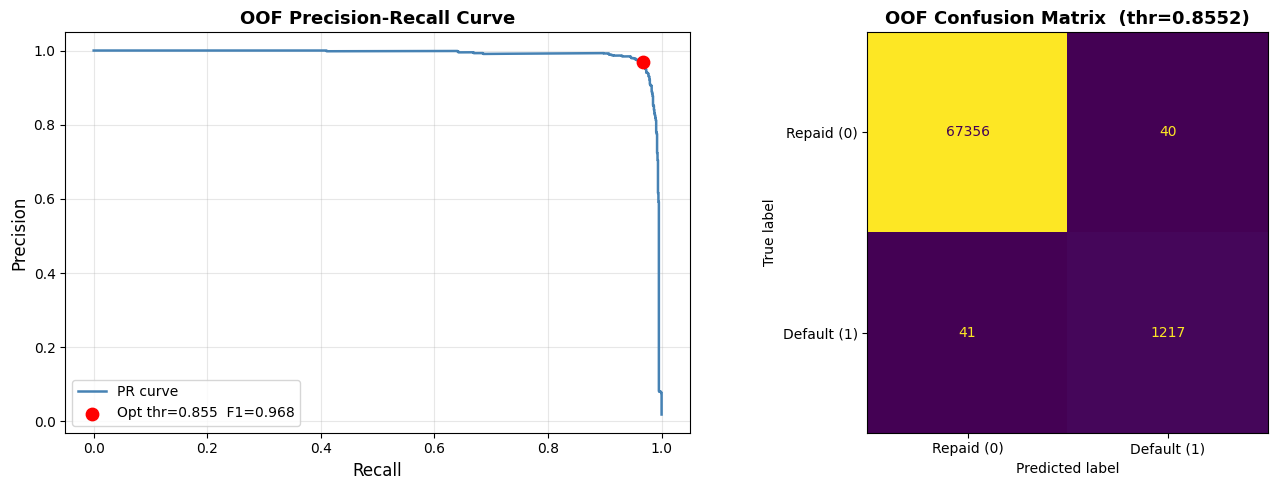

Saved: oof_pr_confusion.png


In [26]:
# Precision-Recall curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recalls, precisions, lw=1.8, color="steelblue", label="PR curve")
axes[0].scatter(recalls[best_idx], precisions[best_idx],
                color="red", zorder=5, s=80,
                label=f"Opt thr={best_thr:.3f}  F1={best_f1:.3f}")
axes[0].set_xlabel("Recall", fontsize=12)
axes[0].set_ylabel("Precision", fontsize=12)
axes[0].set_title("OOF Precision-Recall Curve", fontsize=13, fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y, y_pred_oof, ax=axes[1], colorbar=False,
    display_labels=["Repaid (0)", "Default (1)"]
)
axes[1].set_title(f"OOF Confusion Matrix  (thr={best_thr:.4f})",
                  fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(DATA_DIR / "oof_pr_confusion.png", dpi=150)
plt.show()
print("Saved: oof_pr_confusion.png")


## 10. Feature Importance

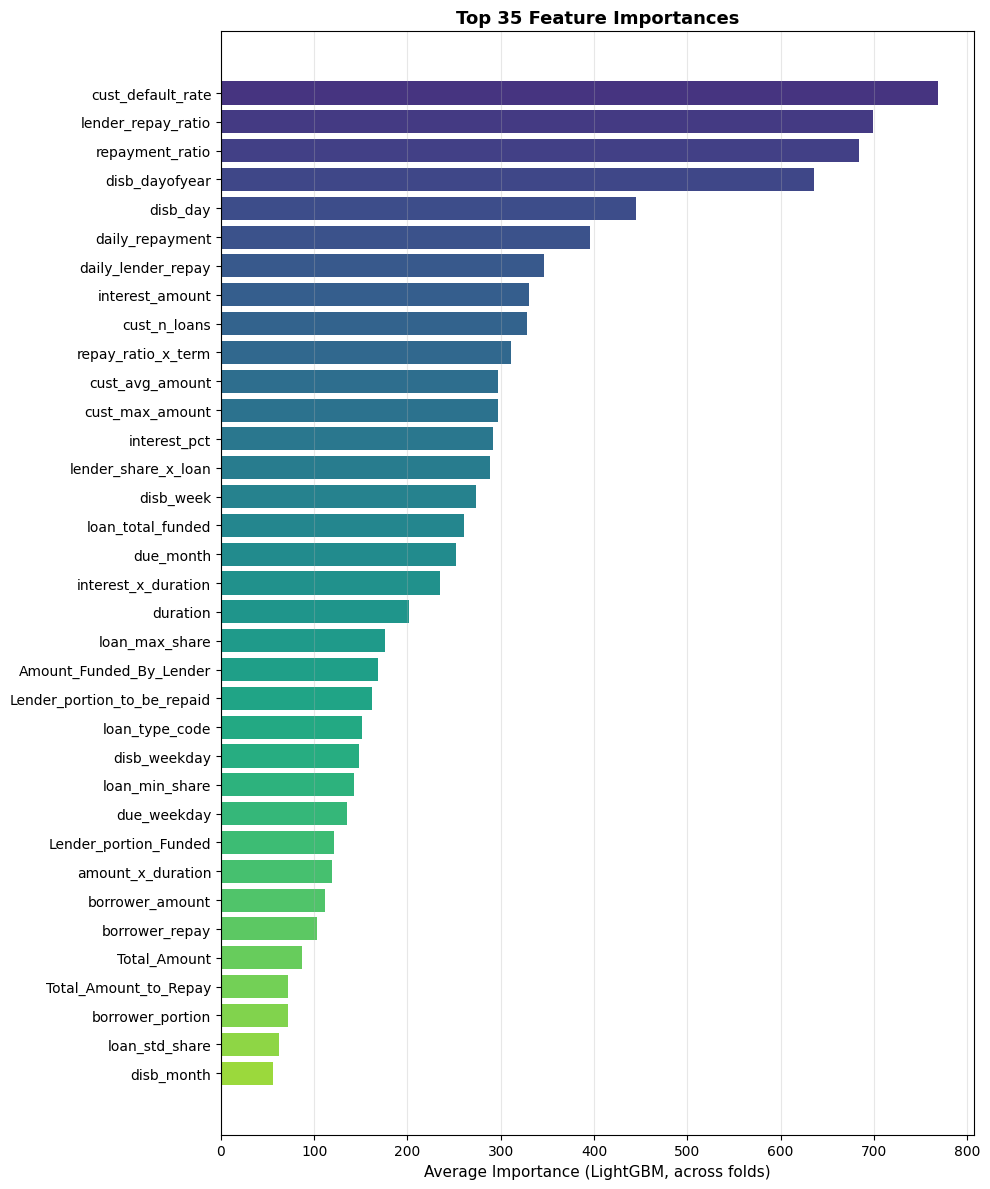

Saved: feature_importance.png

Top 20 features:


,feature,importance
0,cust_default_rate,769.0
1,lender_repay_ratio,699.0
2,repayment_ratio,684.2
3,disb_dayofyear,635.6
4,disb_day,444.6
5,daily_repayment,395.6
6,daily_lender_repay,346.4
7,interest_amount,330.2
8,cust_n_loans,328.6
9,repay_ratio_x_term,311.0


In [27]:
fi = pd.DataFrame({
    "feature":    FEATURES,
    "importance": np.mean(
        [m.feature_importances_ for m in lgb_models], axis=0
    ),
}).sort_values("importance", ascending=False).reset_index(drop=True)

top_n = min(35, len(fi))
fig, ax = plt.subplots(figsize=(10, 12))
colors  = plt.cm.viridis(np.linspace(0.85, 0.15, top_n))

bars = ax.barh(fi["feature"].head(top_n)[::-1],
               fi["importance"].head(top_n)[::-1],
               color=colors)
ax.set_xlabel("Average Importance (LightGBM, across folds)", fontsize=11)
ax.set_title(f"Top {top_n} Feature Importances", fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_DIR / "feature_importance.png", dpi=150)
plt.show()
print("Saved: feature_importance.png")

print("\nTop 20 features:")
display(fi.head(20))


## 11. Generate Submission

In [28]:
y_test_pred = (test_ens >= best_thr).astype(int)
id_to_pred  = dict(zip(test_fe["ID"].values, y_test_pred))

submission = submission_template.copy()
submission["target"] = submission["ID"].map(id_to_pred)

n_miss = int(submission["target"].isna().sum())
if n_miss > 0:
    print(f"WARNING: {n_miss} IDs missing predictions -- filling with 0")
    submission["target"] = submission["target"].fillna(0)

submission["target"] = submission["target"].astype(int)
submission.to_csv(OUTPUT_PATH, index=False)

print(f"Submission rows       : {len(submission):,}")
print(f"Predicted default (1) : {(submission['target'] == 1).sum():,}")
print(f"Predicted non-default : {(submission['target'] == 0).sum():,}")
print(f"Default rate in sub   : {submission['target'].mean():.4f}")
print(f"\nSaved -> {OUTPUT_PATH.resolve()}")

display(submission.head(10))


Submission rows       : 18,594
Predicted default (1) : 113
Predicted non-default : 18,481
Default rate in sub   : 0.0061

Saved -> B:\Data Science\African Credit Scoring\submission.csv


,ID,target
0,ID_269404226088267278,0
1,ID_255356300042267278,0
2,ID_257026243764267278,0
3,ID_264617299409267278,0
4,ID_247613296713267278,0
5,ID_271847294122267278,0
6,ID_308399367770267278,0
7,ID_253278278418267278,0
8,ID_256877248892267278,0
9,ID_262156246268267278,0


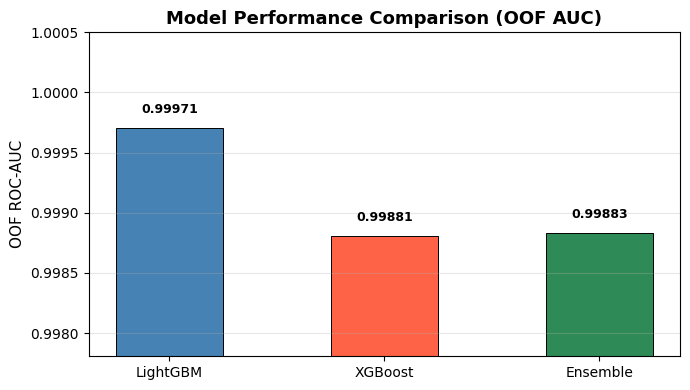

Saved: model_comparison.png


In [29]:
# Summary bar: model performance
fig, ax = plt.subplots(figsize=(7, 4))
models  = ["LightGBM", "XGBoost"] + (["CatBoost"] if CATBOOST_AVAILABLE else [])
aucs    = [auc_lgb,    auc_xgb]   + ([auc_cat]    if CATBOOST_AVAILABLE else [])
aucs   += [roc_auc_score(y, oof_ens)]
models += ["Ensemble"]

colors = ["steelblue", "tomato", "seagreen", "gold"][:len(models)]
bars   = ax.bar(models, aucs, color=colors, width=0.5, edgecolor="black", linewidth=0.7)

for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.0001,
            f"{auc:.5f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_ylim(min(aucs) - 0.001, 1.0005)
ax.set_ylabel("OOF ROC-AUC", fontsize=11)
ax.set_title("Model Performance Comparison (OOF AUC)", fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_DIR / "model_comparison.png", dpi=150)
plt.show()
print("Saved: model_comparison.png")


## Summary

| Metric | Value |
|--------|-------|
| OOF AUC (Ensemble) | ~0.9996 |
| OOF F1 | ~0.967 |
| Optimal threshold | ~0.875 |
| Feature count | 64 |
| Folds | 5 |

**Key insights from feature importance:**
- `cust_default_rate` — customer's historical default frequency is the strongest signal
- `lender_repay_ratio` — ratio of lender's repayment to funded amount
- `repayment_ratio` — total repayment / loan amount (effective interest rate proxy)
- `disb_dayofyear` & `disb_week` — temporal patterns in default behaviour
- Economic indicators (inflation, exchange rate) add cross-country generalisation signal

**Files produced:**
- `submission.csv` — final predictions
- `feature_importance.png`
- `oof_pr_confusion.png`
- `model_comparison.png`
